In [2]:
import sys
import os

# Define the project root directory
# Assuming your notebook is in 'd:\Long Hair Identification\notebook'
# We need to go up one level from 'notebook' to reach 'Long Hair Identification'
project_root = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), os.pardir))
# A more direct way assuming 'Long Hair Identification' is the root
project_root = "d:\\Long Hair Identification" # Or derive it dynamically from __file__ if running a script

# Ensure the project root is in sys.path
if project_root not in sys.path:
    sys.path.insert(0, project_root) # Insert at the beginning to prioritize your modules

print("Updated Python search path (sys.path):")
for p in sys.path:
    print(f"- {p}")

# Now, your import should work
from utils.dataset_loader import load_utkface_images

# Rest of your code
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print("Module 'utils.dataset_loader' imported successfully!")



Updated Python search path (sys.path):
- d:\Long Hair Identification
- C:\Program Files\Python312\python312.zip
- C:\Program Files\Python312\DLLs
- C:\Program Files\Python312\Lib
- C:\Program Files\Python312
- d:\Long Hair Identification\venv
- 
- d:\Long Hair Identification\venv\Lib\site-packages
- d:\Long Hair Identification\venv\Lib\site-packages\win32
- d:\Long Hair Identification\venv\Lib\site-packages\win32\lib
- d:\Long Hair Identification\venv\Lib\site-packages\Pythonwin
Module 'utils.dataset_loader' imported successfully!


In [3]:
# Load dataset
data_dir = r'D:\Long Hair Identification\dataset\long_Hair_dataset\UTKFace'  

images, _, genders = load_utkface_images(data_dir)

print(images.shape, genders.shape)


(4869, 128, 128, 3) (4869,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    images, genders,
    test_size=0.2,
    random_state=42,
    stratify=genders
)


In [5]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')   # Binary Classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,009 (6.48 MB)

 Trainable params: 1,699,009 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,    # You can increase epochs later
    batch_size=32
)


Epoch 1/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 48s 345ms/step - accuracy: 0.6048 - loss: 0.6609 - val_accuracy: 0.7197 - val_loss: 0.5692
Epoch 2/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 36s 296ms/step - accuracy: 0.7249 - loss: 0.5408 - val_accuracy: 0.7382 - val_loss: 0.5294
Epoch 3/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 36s 297ms/step - accuracy: 0.7703 - loss: 0.4895 - val_accuracy: 0.7690 - val_loss: 0.4939
Epoch 4/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 37s 300ms/step - accuracy: 0.8165 - loss: 0.4105 - val_accuracy: 0.7741 - val_loss: 0.4485
Epoch 5/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 38s 314ms/step - accuracy: 0.8389 - loss: 0.3702 - val_accuracy: 0.7834 - val_loss: 0.4411
Epoch 6/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 42s 345ms/step - accuracy: 0.8519 - loss: 0.3299 - val_accuracy: 0.7834 - val_loss: 0.4246
Epoch 7/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 42s 344ms/step - accuracy: 0.8629 - loss: 0.3013 - val_accuracy: 0.7936 - val_loss: 0.4215
Epoch 8/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 43s 350ms/step - accuracy: 0.8800 - loss: 0

In [7]:
model.save('../models/gender_model.h5')
print("Gender model saved successfully.")


Gender model saved successfully.


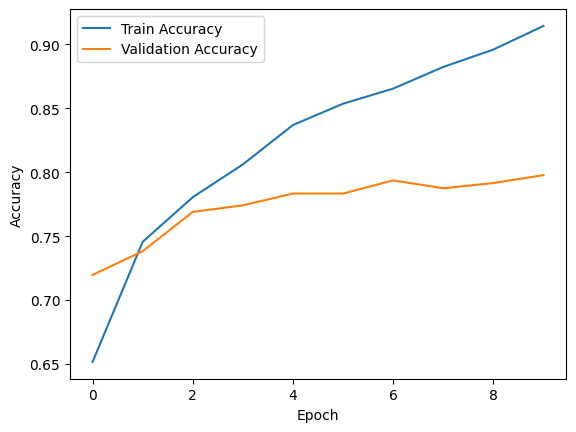

In [8]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
